# Phase 2: Model Training & Evaluation

## Setup — Load Preprocessed Data from Phase 1

In [1]:
# ============================================================
# Install dependencies & restart runtime
# Run this cell, then go to Runtime > Restart session
# ============================================================
!pip install datasets==2.14.7 huggingface_hub==0.21.4 transformers==4.40.2 -q
!pip install underthesea scikit-learn -q
!pip install mlflow -q
print("✅ Done. Now go to Runtime > Restart session, then run the next cell.")

✅ Done. Now go to Runtime > Restart session, then run the next cell.


In [2]:
# ============================================================
# Import libraries and mount Google Drive
# Load preprocessed CSVs saved at the end of Phase 1
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import os
import json
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, accuracy_score, f1_score
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

DATA_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis/data'
train_df = pd.read_csv(f'{DATA_DIR}/train_preprocessed.csv')
val_df = pd.read_csv(f'{DATA_DIR}/val_preprocessed.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test_preprocessed.csv')

print(f"Loaded — Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,}")

# MLflow setup
import mlflow
import mlflow.pytorch

MLFLOW_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis/mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('vietnamese-sentiment-analysis')
print(f"MLflow tracking: {MLFLOW_DIR}")

Mounted at /content/drive
Device: cuda
Loaded — Train: 11,426, Val: 1,583, Test: 3,166
MLflow tracking: /content/drive/MyDrive/phobert-sentiment-analysis/mlruns


In [3]:
# ============================================================
# Rebuild tokenizer, Dataset class, and DataLoaders
# Same config as Phase 1 — MAX_LENGTH=128, BATCH_SIZE=32
# ============================================================
LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']
NUM_CLASSES = 3
MAX_LENGTH = 128
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

class VietnameseSentimentDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe['clean_text'].tolist()
        self.labels = dataframe['sentiment'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = VietnameseSentimentDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = VietnameseSentimentDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = VietnameseSentimentDataset(test_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders ready — Train: {len(train_loader)} batches, Val: {len(val_loader)}, Test: {len(test_loader)}")

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DataLoaders ready — Train: 358 batches, Val: 50, Test: 99


## 2.1 Baseline — TF-IDF + Logistic Regression

In [4]:
# ============================================================
# Baseline: TF-IDF + Logistic Regression — tracked with MLflow
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

with mlflow.start_run(run_name="tfidf-logreg-baseline"):
    mlflow.log_param("model_type", "TF-IDF + LogReg")
    mlflow.log_param("max_features", 20000)
    mlflow.log_param("ngram_range", "(1, 2)")
    mlflow.log_param("C", 1.0)

    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
    X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
    X_val_tfidf = tfidf.transform(val_df['clean_text'])
    X_test_tfidf = tfidf.transform(test_df['clean_text'])

    lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    lr_model.fit(X_train_tfidf, train_df['sentiment'])

    y_val_pred = lr_model.predict(X_val_tfidf)
    y_test_pred = lr_model.predict(X_test_tfidf)

    val_acc = accuracy_score(val_df['sentiment'], y_val_pred)
    test_acc = accuracy_score(test_df['sentiment'], y_test_pred)
    test_f1 = f1_score(test_df['sentiment'], y_test_pred, average='macro')

    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_f1_macro", test_f1)

    print("=== Baseline — Validation Set ===")
    print(f"Accuracy: {val_acc:.4f}")
    print(classification_report(val_df['sentiment'], y_val_pred, target_names=LABEL_NAMES))

    print("=== Baseline — Test Set ===")
    print(f"Accuracy: {test_acc:.4f}")
    print(classification_report(test_df['sentiment'], y_test_pred, target_names=LABEL_NAMES))

=== Baseline — Validation Set ===
Accuracy: 0.9109
              precision    recall  f1-score   support

    Negative       0.89      0.96      0.92       705
     Neutral       0.86      0.08      0.15        73
    Positive       0.93      0.94      0.94       805

    accuracy                           0.91      1583
   macro avg       0.89      0.66      0.67      1583
weighted avg       0.91      0.91      0.89      1583

=== Baseline — Test Set ===
Accuracy: 0.8907
              precision    recall  f1-score   support

    Negative       0.86      0.97      0.91      1409
     Neutral       0.71      0.06      0.11       167
    Positive       0.93      0.91      0.92      1590

    accuracy                           0.89      3166
   macro avg       0.83      0.65      0.65      3166
weighted avg       0.88      0.89      0.87      3166



In [5]:
# ============================================================
# Store baseline results for later comparison (Phase 3)
# ============================================================
results = {
    'model': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'test_f1_macro': []
}

results['model'].append('TF-IDF + LogReg')
results['val_accuracy'].append(accuracy_score(val_df['sentiment'], y_val_pred))
results['test_accuracy'].append(accuracy_score(test_df['sentiment'], y_test_pred))
results['test_f1_macro'].append(f1_score(test_df['sentiment'], y_test_pred, average='macro'))

## 2.2 PhoBERT Fine-Tuning

In [6]:
# ============================================================
# Load PhoBERT with a 3-class classification head
# ============================================================
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/phobert-base',
    num_labels=NUM_CLASSES
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Device: {device}")
print(f"Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: cuda
Total parameters:     135,000,579
Trainable parameters: 135,000,579


In [7]:
# ============================================================
# Optimizer and learning rate scheduler
# AdamW with linear warmup prevents early training instability
# ============================================================
from transformers import get_linear_schedule_with_warmup

EPOCHS = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Epochs: {EPOCHS}, Total steps: {total_steps}, Warmup steps: {warmup_steps}")

Epochs: 4, Total steps: 1432, Warmup steps: 143


In [8]:
# ============================================================
# Training and evaluation helper functions
# Separated for clarity and reuse in the training loop
# ============================================================
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)

In [9]:
# ============================================================
# Training loop with early stopping — tracked with MLflow
# ============================================================
CHECKPOINT_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

PATIENCE = 2  # FIX: define as constant, not reassigned inside loop

# --- Helper: save full training state for resume ---
def save_checkpoint(model, optimizer, scheduler, epoch, best_val_f1, history, path):
    """Save model + optimizer/scheduler/epoch so training can resume."""
    model.save_pretrained(path)
    tokenizer.save_pretrained(path)
    torch.save({
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'best_val_f1': best_val_f1,
        'history': history,
    }, os.path.join(path, 'training_state.pt'))

def load_checkpoint(model, optimizer, scheduler, path):
    """Resume training from saved checkpoint. Returns (start_epoch, best_f1, history)."""
    state_path = os.path.join(path, 'training_state.pt')
    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        optimizer.load_state_dict(state['optimizer_state_dict'])
        scheduler.load_state_dict(state['scheduler_state_dict'])
        print(f"Resumed from epoch {state['epoch']+1}, best F1: {state['best_val_f1']:.4f}")
        return state['epoch'] + 1, state['best_val_f1'], state['history']
    return 0, 0.0, {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

# --- Attempt to resume from previous checkpoint ---
start_epoch, best_val_f1, history = load_checkpoint(model, optimizer, scheduler, CHECKPOINT_DIR)

with mlflow.start_run(run_name="phobert-finetune"):
    mlflow.log_param("model_name", "vinai/phobert-base")
    mlflow.log_param("max_length", MAX_LENGTH)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("warmup_ratio", WARMUP_RATIO)
    mlflow.log_param("weight_decay", 0.01)
    mlflow.log_param("patience", PATIENCE)

    patience_counter = 0

    for epoch in range(start_epoch, EPOCHS):  # FIX: start from resume point, not 0
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print(f"{'='*50}")

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_acc", train_acc, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_acc", val_acc, step=epoch)
        mlflow.log_metric("val_f1", val_f1, step=epoch)

        print(f"Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
        print(f"Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            save_checkpoint(model, optimizer, scheduler, epoch, best_val_f1, history, CHECKPOINT_DIR)
            print(f">>> Best model saved (full checkpoint)! F1: {best_val_f1:.4f}")
        else:
            patience_counter += 1
            print(f">>> No improvement. Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

    mlflow.log_metric("best_val_f1", best_val_f1)
    mlflow.log_metric("stopped_at_epoch", len(history['train_loss']))

    print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")

Resumed from epoch 2, best F1: 0.8568

Epoch 3/4


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Train — Loss: 0.3325, Acc: 0.8876
Val   — Loss: 0.2278, Acc: 0.9318, F1: 0.7056
>>> No improvement. Patience: 1/2

Epoch 4/4


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Train — Loss: 0.1862, Acc: 0.9421
Val   — Loss: 0.1980, Acc: 0.9438, F1: 0.8081
>>> No improvement. Patience: 2/2
Early stopping triggered.

Training complete. Best val F1: 0.8568


## 2.3 Test Set Evaluation

In [10]:
# ============================================================
# Load best checkpoint and evaluate on held-out test set
# ============================================================
best_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_DIR)
best_model.to(device)

test_loader_eval = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(best_model, test_loader_eval, device)

print("=== PhoBERT — Test Set ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Macro: {test_f1:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=LABEL_NAMES))

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

=== PhoBERT — Test Set ===
Accuracy: 0.9406
F1 Macro: 0.8410

              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96      1409
     Neutral       0.67      0.56      0.61       167
    Positive       0.96      0.96      0.96      1590

    accuracy                           0.94      3166
   macro avg       0.86      0.83      0.84      3166
weighted avg       0.94      0.94      0.94      3166



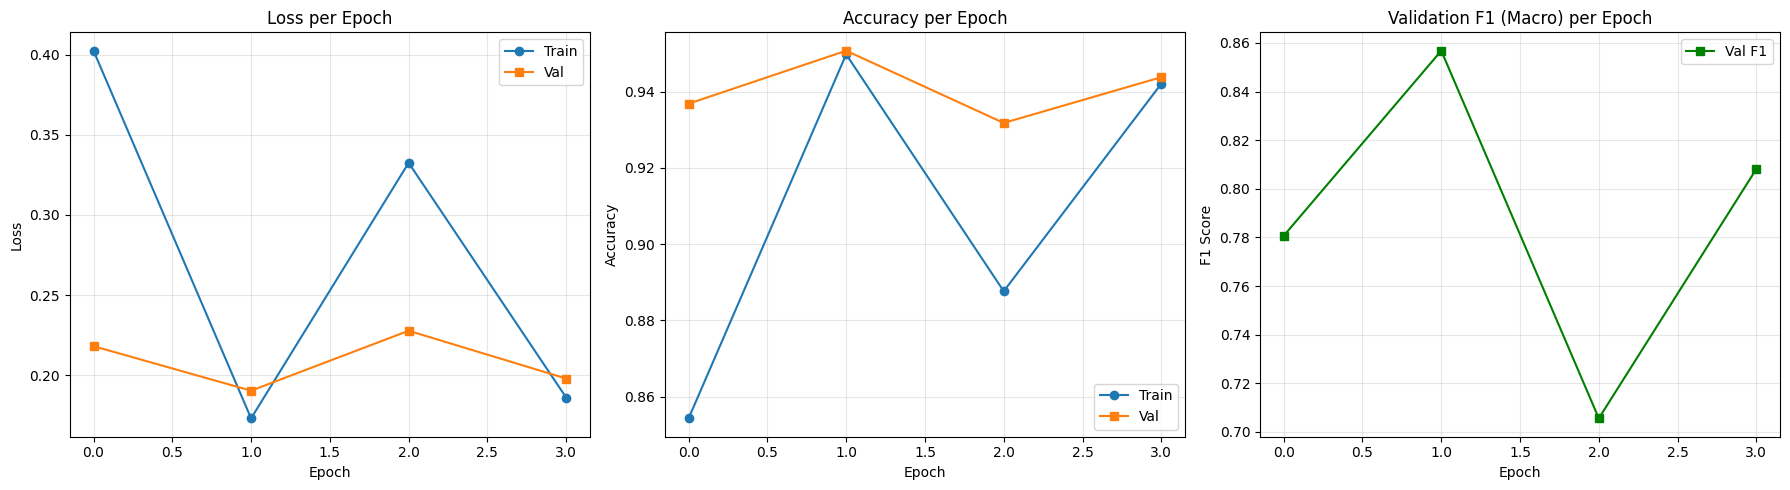

In [11]:
# ============================================================
# Training curves — track overfitting and convergence
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], 'o-', label='Train')
axes[0].plot(history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], 'o-', label='Train')
axes[1].plot(history['val_acc'], 's-', label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_f1'], 's-', label='Val F1', color='green')
axes[2].set_title('Validation F1 (Macro) per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phobert-sentiment-analysis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

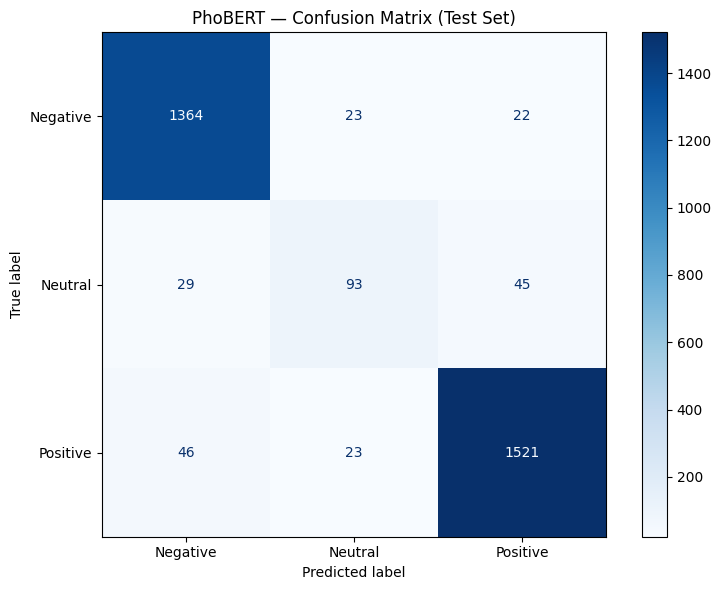


Per-class accuracy:
  Negative: 0.9681 (1364/1409)
  Neutral: 0.5569 (93/167)
  Positive: 0.9566 (1521/1590)


In [12]:
# ============================================================
# Confusion matrix — reveals which classes the model confuses
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('PhoBERT — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phobert-sentiment-analysis/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class accuracy:")
for i, label in enumerate(LABEL_NAMES):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"  {label}: {class_acc:.4f} ({cm[i, i]}/{cm[i].sum()})")

In [13]:
# ============================================================
# Update results table — baseline vs PhoBERT side by side
# ============================================================
results['model'].append('PhoBERT (fine-tuned)')
results['val_accuracy'].append(max(history['val_acc']))
results['test_accuracy'].append(test_acc)
results['test_f1_macro'].append(test_f1)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

               model  val_accuracy  test_accuracy  test_f1_macro
     TF-IDF + LogReg      0.910929       0.890714       0.645871
PhoBERT (fine-tuned)      0.950726       0.940619       0.840971


In [14]:
# ============================================================
# Save training history and results for Phase 3 analysis
# ============================================================
import json

artifacts_dir = '/content/drive/MyDrive/phobert-sentiment-analysis'

with open(f'{artifacts_dir}/training_history.json', 'w') as f:
    json.dump(history, f)

results_df.to_csv(f'{artifacts_dir}/model_results.csv', index=False)

# Save test predictions for error analysis in Phase 3
test_df['phobert_pred'] = test_preds
test_df.to_csv(f'{artifacts_dir}/data/test_with_predictions.csv', index=False)

print("Saved: training_history.json, model_results.csv, test_with_predictions.csv")

Saved: training_history.json, model_results.csv, test_with_predictions.csv


In [15]:
# ============================================================
# View all MLflow experiment runs in one table
# ============================================================
experiment = mlflow.get_experiment_by_name('vietnamese-sentiment-analysis')
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

display_cols = [c for c in [
    'run_name', 'params.model_type', 'params.model_name',
    'params.learning_rate', 'metrics.val_accuracy',
    'metrics.test_accuracy', 'metrics.test_f1_macro', 'metrics.best_val_f1'
] if c in runs_df.columns]

print("=== MLflow Experiment Runs ===")
print(runs_df[display_cols].to_string(index=False))

=== MLflow Experiment Runs ===
params.model_type  params.model_name params.learning_rate  metrics.val_accuracy  metrics.test_accuracy  metrics.test_f1_macro  metrics.best_val_f1
             None vinai/phobert-base                2e-05                   NaN                    NaN                    NaN             0.856788
  TF-IDF + LogReg               None                 None              0.910929               0.890714               0.645871                  NaN
             None vinai/phobert-base                2e-05                   NaN                    NaN                    NaN             0.856788
  TF-IDF + LogReg               None                 None              0.909665               0.890398               0.645653                  NaN
             None vinai/phobert-base                2e-05                   NaN                    NaN                    NaN             0.838150
  TF-IDF + LogReg               None                 None              0.909665        

## 2.4 Hyperparameter Tuning with Optuna

In [16]:
# ============================================================
# Install Optuna
# ============================================================
!pip install optuna -q
import optuna
from optuna.trial import TrialState

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.8 MB/s eta 0:00:00


In [17]:
# ============================================================
# Define Optuna objective — each trial trains PhoBERT 2 epochs
# Tunes learning rate, warmup ratio, and weight decay
# ============================================================
def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.0, 0.2)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.1)

    TUNE_EPOCHS = 2

    # Fresh model for each trial
    tune_model = AutoModelForSequenceClassification.from_pretrained(
        'vinai/phobert-base', num_labels=NUM_CLASSES
    ).to(device)

    tune_optimizer = torch.optim.AdamW(
        tune_model.parameters(), lr=lr, weight_decay=weight_decay
    )

    total_steps = len(train_loader) * TUNE_EPOCHS
    tune_scheduler = get_linear_schedule_with_warmup(
        tune_optimizer,
        num_warmup_steps=int(total_steps * warmup_ratio),
        num_training_steps=total_steps
    )

    best_f1 = 0
    for epoch in range(TUNE_EPOCHS):
        train_loss, train_acc = train_epoch(
            tune_model, train_loader, tune_optimizer, tune_scheduler, device
        )
        val_loss, val_acc, val_f1, _, _ = evaluate(tune_model, val_loader, device)
        best_f1 = max(best_f1, val_f1)

        # Report to Optuna for pruning
        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # Cleanup GPU memory
    del tune_model, tune_optimizer, tune_scheduler
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return best_f1

In [18]:
# ============================================================
# Run Optuna study — 5 trials with MedianPruner
# ~25-30 min on T4 GPU, finds optimal hyperparameters
# ============================================================
study = optuna.create_study(
    direction="maximize",
    study_name="phobert-hparam-search",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2)
)

study.optimize(objective, n_trials=5, show_progress_bar=True)

print("\n" + "=" * 50)
print("OPTUNA RESULTS")
print("=" * 50)
print(f"Best trial F1: {study.best_trial.value:.4f}")
print(f"Best params:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2026-03-13 08:01:37,352] A new study created in memory with name: phobert-hparam-search


  0%|          | 0/5 [00:00<?, ?it/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

...

[I 2026-03-13 08:35:03,089] Trial 3 pruned. 


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-13 08:39:59,779] Trial 4 pruned. 

OPTUNA RESULTS
Best trial F1: 0.8546
Best params:
  learning_rate: 4.3761076440630325e-05
  warmup_ratio: 0.18994508235220045
  weight_decay: 0.08896981195897445


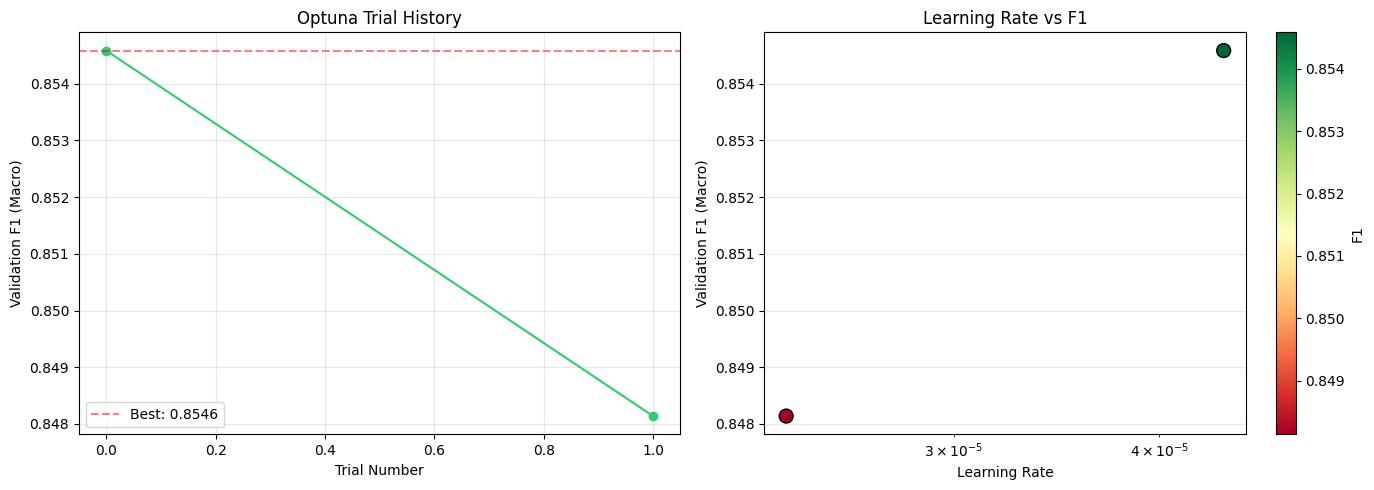

In [19]:
# ============================================================
# Visualize Optuna results — parameter importance and history
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
trial_nums = [t.number for t in trials]
trial_values = [t.value for t in trials]

axes[0].plot(trial_nums, trial_values, 'o-', color='#2ecc71')
axes[0].axhline(y=max(trial_values), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(trial_values):.4f}')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Validation F1 (Macro)')
axes[0].set_title('Optuna Trial History')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Parameter values vs F1
lrs = [t.params['learning_rate'] for t in trials]
f1s = [t.value for t in trials]
scatter = axes[1].scatter(lrs, f1s, c=f1s, cmap='RdYlGn', s=100, edgecolors='black')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Validation F1 (Macro)')
axes[1].set_title('Learning Rate vs F1')
axes[1].set_xscale('log')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='F1')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phobert-sentiment-analysis/optuna_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ============================================================
# Log Optuna best trial to MLflow
# ============================================================
with mlflow.start_run(run_name="optuna-best-trial"):
    mlflow.log_param("model_name", "vinai/phobert-base")
    mlflow.log_param("tuning_method", "Optuna")
    mlflow.log_param("n_trials", len(study.trials))
    mlflow.log_param("tune_epochs_per_trial", 2)

    for key, value in study.best_trial.params.items():
        mlflow.log_param(f"best_{key}", value)

    mlflow.log_metric("best_trial_val_f1", study.best_trial.value)

print("Optuna best trial logged to MLflow.")

Optuna best trial logged to MLflow.


In [21]:
# ============================================================
# Retrain with best Optuna params for full epochs
# This is the final production model
# ============================================================
best_params = study.best_trial.params
print(f"Retraining with best params: {best_params}")

FINAL_EPOCHS = 4
FINAL_PATIENCE = 2

final_model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/phobert-base', num_labels=NUM_CLASSES
).to(device)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=best_params['learning_rate'],
    weight_decay=best_params['weight_decay']
)

total_steps = len(train_loader) * FINAL_EPOCHS
final_scheduler = get_linear_schedule_with_warmup(
    final_optimizer,
    num_warmup_steps=int(total_steps * best_params['warmup_ratio']),
    num_training_steps=total_steps
)

FINAL_CHECKPOINT_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis/checkpoints-optuna'
os.makedirs(FINAL_CHECKPOINT_DIR, exist_ok=True)

# --- Resume support for Optuna retrain ---
start_epoch, best_final_f1, final_history = load_checkpoint(
    final_model, final_optimizer, final_scheduler, FINAL_CHECKPOINT_DIR
)
patience_counter = 0

with mlflow.start_run(run_name="phobert-optuna-best-retrain"):
    mlflow.log_params(best_params)
    mlflow.log_param("model_name", "vinai/phobert-base")
    mlflow.log_param("epochs", FINAL_EPOCHS)
    mlflow.log_param("tuning_method", "Optuna-retrain")

    for epoch in range(start_epoch, FINAL_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{FINAL_EPOCHS}")
        train_loss, train_acc = train_epoch(
            final_model, train_loader, final_optimizer, final_scheduler, device
        )
        val_loss, val_acc, val_f1, _, _ = evaluate(final_model, val_loader, device)

        # Track history for checkpoint saving and later analysis
        final_history['train_loss'].append(train_loss)
        final_history['train_acc'].append(train_acc)
        final_history['val_loss'].append(val_loss)
        final_history['val_acc'].append(val_acc)
        final_history['val_f1'].append(val_f1)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_f1", val_f1, step=epoch)

        print(f"Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_final_f1:
            best_final_f1 = val_f1
            patience_counter = 0
            save_checkpoint(
                final_model, final_optimizer, final_scheduler,
                epoch, best_final_f1, final_history, FINAL_CHECKPOINT_DIR
            )
            print(f">>> Best model saved (full checkpoint)! F1: {best_final_f1:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= FINAL_PATIENCE:
                print("Early stopping.")
                break

    # Evaluate on test
    final_model_loaded = AutoModelForSequenceClassification.from_pretrained(FINAL_CHECKPOINT_DIR).to(device)
    test_loader_eval = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    _, final_test_acc, final_test_f1, final_test_preds, final_test_labels = evaluate(final_model_loaded, test_loader_eval, device)

    mlflow.log_metric("test_accuracy", final_test_acc)
    mlflow.log_metric("test_f1_macro", final_test_f1)

    print(f"\n=== Optuna-tuned PhoBERT — Test Set ===")
    print(f"Accuracy: {final_test_acc:.4f}")
    print(f"F1 Macro: {final_test_f1:.4f}")

# Update results
results['model'].append('PhoBERT (Optuna-tuned)')
results['val_accuracy'].append(best_final_f1)
results['test_accuracy'].append(final_test_acc)
results['test_f1_macro'].append(final_test_f1)

results_df = pd.DataFrame(results)
print("\n=== All Results ===")
print(results_df.to_string(index=False))

Retraining with best params: {'learning_rate': 4.3761076440630325e-05, 'warmup_ratio': 0.18994508235220045, 'weight_decay': 0.08896981195897445}


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/4


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

...

Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Train Loss: 0.0770, Val Acc: 0.9539, Val F1: 0.8692
>>> Best model saved (full checkpoint)! F1: 0.8692


Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]


=== Optuna-tuned PhoBERT — Test Set ===
Accuracy: 0.9384
F1 Macro: 0.8278

=== All Results ===
                 model  val_accuracy  test_accuracy  test_f1_macro
       TF-IDF + LogReg      0.910929       0.890714       0.645871
  PhoBERT (fine-tuned)      0.950726       0.940619       0.840971
PhoBERT (Optuna-tuned)      0.869186       0.938408       0.827838


In [22]:
# Save Optuna-tuned predictions for Phase 3 comparison
test_df['phobert_optuna_pred'] = final_test_preds
test_df.to_csv(f'{artifacts_dir}/data/test_with_predictions.csv', index=False)

# Save updated results
results_df.to_csv(f'{artifacts_dir}/model_results.csv', index=False)

# Save Optuna retrain history
with open(f'{artifacts_dir}/optuna_retrain_history.json', 'w') as f:
    json.dump(final_history, f)

print("Saved: test_with_predictions.csv (updated), model_results.csv, optuna_retrain_history.json")

Saved: test_with_predictions.csv (updated), model_results.csv, optuna_retrain_history.json
